In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device: cpu


In [2]:
batch_size = 128 # batch size 수정가능

# MNIST용 평균 및 표준편차 (1채널 흑백)
mnist_mean = (0.1307,)
mnist_std = (0.3081,)

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std)
])

# CIFAR10 -> MNIST로 변경
full_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform_train
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform_test
)

# 증강 데이터셋 (손글씨 숫자는 좌우 반전 시 의미가 달라지므로 RandomHorizontalFlip 제외)
transform_aug = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomCrop(28, padding=2), # MNIST 크기(28x28)에 맞춤
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std)
])

aug_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform_aug
)

# train/val split
num_train = len(full_train_dataset)
indices = np.random.permutation(num_train)

split = int(num_train * 0.8)
train_indices = indices[:split]
val_indices = indices[split:]

train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_train_dataset, val_indices)

# train/val/test loader
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

# 증강 데이터셋 서브셋 및 로더
aug_train_subset = torch.utils.data.Subset(aug_train_dataset, train_indices)

aug_train_loader = torch.utils.data.DataLoader(
    aug_train_subset, batch_size=batch_size, shuffle=True
)

In [3]:
class MLP_recursive_Float32(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Layer 1
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=1, kernel_size=28, stride=12, bias=False),
            nn.ReLU() # 복잡한 양자화 레이어 없이 평범한 ReLU 사용
        )

        self.flatten = nn.Flatten()

        # Layer 2 ~ 4
        self.classifier = nn.Sequential(
            nn.Linear(64, 128, bias=False),
            nn.ReLU(),

            nn.Linear(128, 64, bias=False),
            nn.ReLU(),

            nn.Linear(64, num_classes, bias=False)
        )

    def forward(self, x):
        x = x.view(x.size(0), 1, 784)
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [4]:
def extract_and_save_int8_weights(model):
    # 1. 모델 가중치 텐서 가져오기
    w_conv1d = model.features[0].weight.data
    w_linear1 = model.classifier[0].weight.data
    w_linear2 = model.classifier[2].weight.data
    w_linear3 = model.classifier[4].weight.data

    # 2. 각 가중치의 절댓값 최대치(Max Absolute Value) 찾기
    max_w_conv1d = torch.max(torch.abs(w_conv1d)).item()
    max_w_linear1 = torch.max(torch.abs(w_linear1)).item()
    max_w_linear2 = torch.max(torch.abs(w_linear2)).item()
    max_w_linear3 = torch.max(torch.abs(w_linear3)).item()

    # 3. 실수형 스케일(Scale) 계산 (C 코드에 넣을 값) -> Max / 127.0
    scale_conv1d = max_w_conv1d / 127.0
    scale_linear1 = max_w_linear1 / 127.0
    scale_linear2 = max_w_linear2 / 127.0
    scale_linear3 = max_w_linear3 / 127.0

    print("=== C 코드용 새로운 스케일 값 ===")
    print(f"weight_Conv1d_scale = {scale_conv1d:.16f};")
    print(f"weight_Linear1_scale = {scale_linear1:.16f};")
    print(f"weight_Linear2_scale = {scale_linear2:.16f};")
    print(f"weight_Linear3_scale = {scale_linear3:.16f};")

    # 4. 가중치를 INT8로 양자화 (Weight / Scale 후 반올림)
    q_w_conv1d = torch.clamp(torch.round(w_conv1d / scale_conv1d), -128, 127).to(torch.int8)
    q_w_linear1 = torch.clamp(torch.round(w_linear1 / scale_linear1), -128, 127).to(torch.int8)
    q_w_linear2 = torch.clamp(torch.round(w_linear2 / scale_linear2), -128, 127).to(torch.int8)
    q_w_linear3 = torch.clamp(torch.round(w_linear3 / scale_linear3), -128, 127).to(torch.int8)
    
    def save_to_txt(filename, tensor):
            flattened = tensor.flatten().cpu().numpy()
            with open(filename, "w") as f:
                for val in flattened:
                    f.write(f"{val}\n")
    
    save_to_txt("int8_weight_Conv1d_dec.txt", q_w_conv1d)
    save_to_txt("int8_weight_Linear1_dec.txt", q_w_linear1)
    save_to_txt("int8_weight_Linear2_dec.txt", q_w_linear2)
    save_to_txt("int8_weight_Linear3_dec.txt", q_w_linear3)
    
    print("\nINT8 가중치 txt 파일 저장 완료!")

In [5]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = out.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)

        total_loss += loss.item() * x.size(0)
        pred = out.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

def run_training(model, train_loader, val_loader, lr=1e-3, epochs=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }

    start = time.time()
    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(f"[{epoch+1}/{epochs}] "
              f"train_loss={tr_loss:.4f}, train_acc={tr_acc:.4f}, "
              f"val_loss={va_loss:.4f}, val_acc={va_acc:.4f}")

    elapsed = time.time() - start
    return model, history, elapsed

def plot_history(history, title="History"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"], label="val")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train")
    plt.plot(epochs, history["val_acc"], label="val")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

def generalization_gap(history):
    return history["train_acc"][-1] - history["val_acc"][-1]

In [6]:
def extract_activation_scales(model, data_loader, device):
    model.eval()
    # 각 레이어의 출력 최댓값을 저장할 리스트
    max_vals = {
        'layer1': 0.0,
        'layer2': 0.0,
        'layer3': 0.0
    }

    with torch.no_grad():
        # 약 1000개 정도의 이미지만 확인해도 충분함
        for i, (images, _) in enumerate(data_loader):
            if i > 10: break # batch_size=128 기준 약 1280개
            
            images = images.to(device).view(images.size(0), 1, 784)
            
            # 레이어별 출력을 직접 추적
            # 1. Layer 1 (Conv1d) 출력
            out1 = F.relu(model.features[0](images))
            max_vals['layer1'] = max(max_vals['layer1'], torch.max(torch.abs(out1)).item())
            
            # 2. Layer 2 (Linear 1) 출력
            out1_flat = out1.view(out1.size(0), -1)
            out2 = F.relu(model.classifier[0](out1_flat))
            max_vals['layer2'] = max(max_vals['layer2'], torch.max(torch.abs(out2)).item())
            
            # 3. Layer 3 (Linear 2) 출력
            out3 = F.relu(model.classifier[2](out2))
            max_vals['layer3'] = max(max_vals['layer3'], torch.max(torch.abs(out3)).item())

    # INT8 스케일 계산 (Max / 127.0)
    scales = {k: v / 127.0 for k, v in max_vals.items()}
    
    print("=== C 코드용 새로운 레이어(Activation) 스케일 값 ===")
    for k, v in scales.items():
        print(f"{k}_scale = {v:.16f};")
        
    return scales

In [7]:
epochs = 10
lr = 1e-3

results = {}

MLP params: 17052
[1/10] train_loss=0.6338, train_acc=0.8246, val_loss=0.3143, val_acc=0.9083
[2/10] train_loss=0.2679, train_acc=0.9197, val_loss=0.2450, val_acc=0.9230
[3/10] train_loss=0.2056, train_acc=0.9384, val_loss=0.2041, val_acc=0.9390
[4/10] train_loss=0.1725, train_acc=0.9475, val_loss=0.1741, val_acc=0.9457
[5/10] train_loss=0.1495, train_acc=0.9537, val_loss=0.1594, val_acc=0.9495
[6/10] train_loss=0.1328, train_acc=0.9593, val_loss=0.1555, val_acc=0.9517
[7/10] train_loss=0.1198, train_acc=0.9629, val_loss=0.1404, val_acc=0.9579
[8/10] train_loss=0.1106, train_acc=0.9653, val_loss=0.1334, val_acc=0.9585
[9/10] train_loss=0.1007, train_acc=0.9686, val_loss=0.1288, val_acc=0.9597
[10/10] train_loss=0.0931, train_acc=0.9710, val_loss=0.1208, val_acc=0.9636


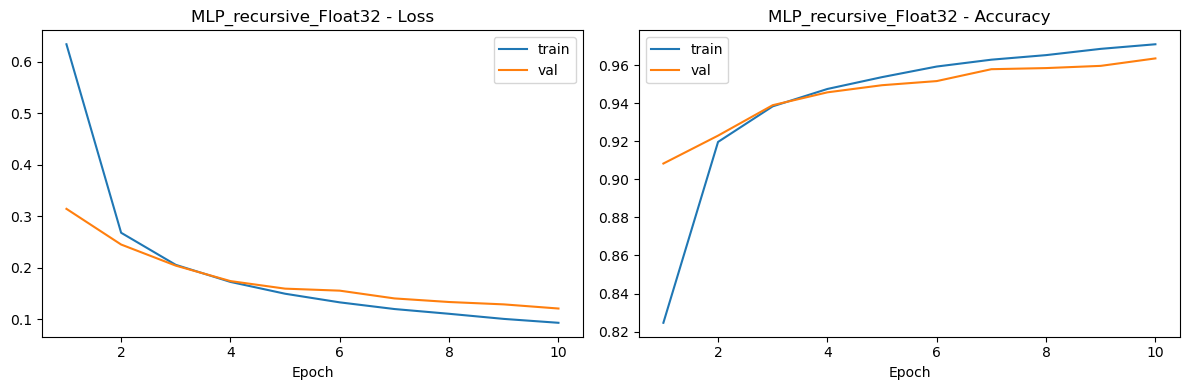

Training time: 83.73 seconds
Training time: 1.40 minutes
--- Final MLP Results ---
Final Train Loss: 0.0931
Final Val Loss: 0.1208
Final Train Acc: 0.9710
Final Val Acc: 0.9636
Generalization Gap: 0.0074


In [8]:
mlp_model = MLP_recursive_Float32()


print("MLP params:", count_parameters(mlp_model))
mlp_model, mlp_history, mlp_time = run_training(
    mlp_model, train_loader, val_loader, lr=lr, epochs=epochs
)
plot_history(mlp_history, title="MLP_recursive_Float32")
print(f"Training time: {mlp_time:.2f} seconds")
print(f"Training time: {mlp_time/60:.2f} minutes")

final_train_loss = mlp_history["train_loss"][-1]
final_val_loss = mlp_history["val_loss"][-1]
final_train_acc = mlp_history["train_acc"][-1]
final_val_acc = mlp_history["val_acc"][-1]
gap = generalization_gap(mlp_history)

print(f"--- Final MLP Results ---")
print(f"Final Train Loss: {final_train_loss:.4f}")
print(f"Final Val Loss: {final_val_loss:.4f}")
print(f"Final Train Acc: {final_train_acc:.4f}")
print(f"Final Val Acc: {final_val_acc:.4f}")
print(f"Generalization Gap: {gap:.4f}")

In [9]:
extract_and_save_int8_weights(mlp_model)

=== C 코드용 새로운 스케일 값 ===
weight_Conv1d_scale = 0.0058014801168066;
weight_Linear1_scale = 0.0071993188595209;
weight_Linear2_scale = 0.0059023203812246;
weight_Linear3_scale = 0.0039204441186950;

INT8 가중치 txt 파일 저장 완료!


In [11]:
act_scales = extract_activation_scales(mlp_model, test_loader, device)

=== C 코드용 새로운 레이어(Activation) 스케일 값 ===
layer1_scale = 0.1105961161335622;
layer2_scale = 0.0806436989251084;
layer3_scale = 0.1170919823834277;
